In [212]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score

In [213]:
# Load the dataset
dataset = pd.read_csv("../../Data/Churn Prediction Data/churn-bigml-20.csv")

print(dataset.head())

  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95   

In [214]:
# Dataset's all details
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [215]:
# Various measures of the numerical data
print(dataset.describe())

       Account length   Area code  Number vmail messages  Total day minutes  \
count      667.000000  667.000000             667.000000         667.000000   
mean       102.841079  436.157421               8.407796         180.948126   
std         40.819480   41.783305              13.994480          55.508628   
min          1.000000  408.000000               0.000000          25.900000   
25%         76.000000  408.000000               0.000000         146.250000   
50%        102.000000  415.000000               0.000000         178.300000   
75%        128.000000  415.000000              20.000000         220.700000   
max        232.000000  510.000000              51.000000         334.300000   

       Total day calls  Total day charge  Total eve minutes  Total eve calls  \
count       667.000000        667.000000         667.000000       667.000000   
mean        100.937031         30.761769         203.355322       100.476762   
std          20.396790          9.436463        

In [216]:
# Checking for missing values
print(dataset.isna().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [217]:
# Checking for duplicated data
print(dataset.duplicated().sum())

0


In [218]:
# Converting categorical data to numerical data
dataset['International plan'] = dataset['International plan'].map({'Yes': 1, 'No': 0})
dataset['Voice mail plan'] = dataset['Voice mail plan'].map({'Yes': 1, 'No': 0})
dataset['Churn'] = dataset['Churn'].astype(int)
dataset = pd.get_dummies(dataset, columns=['State'], drop_first=True).astype(int)

In [219]:
# Rearranging columns
cols = ["Churn"]
dataset = dataset[cols + [col for col in dataset.columns if col not in cols]]
print(dataset.head())

   Churn  Account length  Area code  International plan  Voice mail plan  \
0      0             117        408                   0                0   
1      1              65        415                   0                0   
2      1             161        415                   0                0   
3      0             111        415                   0                0   
4      0              49        510                   0                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0                184               97   
1                      0                129              137   
2                      0                332               67   
3                      0                110              103   
4                      0                119              117   

   Total day charge  Total eve minutes  ...  State_SD  State_TN  State_TX  \
0                31                351  ...         0         0         0   
1   

In [220]:
# Converting data ready for features selection
data = dataset.values

In [221]:
# Features selection
X = data[:,1:]
y = data[:, 0]

In [222]:
# Spliting train/test
# 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [223]:
# Printing shapes for splited data to confirm the spliting

print("X_train shape = ", X_train.shape)
print("X_test shape = ", X_test.shape)
print("y_train shape = ", y_train.shape)
print("y_test shape = ", y_test.shape)

X_train shape =  (533, 68)
X_test shape =  (134, 68)
y_train shape =  (533,)
y_test shape =  (134,)


In [224]:
# Original Random Forest model
rfc = RandomForestClassifier(random_state=0)

# Model fitting
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [225]:
# Prediction
y_pred = rfc.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8880597014925373

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       115
           1       0.83      0.26      0.40        19

    accuracy                           0.89       134
   macro avg       0.86      0.63      0.67       134
weighted avg       0.88      0.89      0.86       134



In [226]:
# Parameters grid for Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15]
}

In [227]:
# GridSearchCV for finding tuned parameters
rfc_grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [228]:
# Fitting model
rfc_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [229]:
# Tuned parameters search by grid search
print("Tuned Parameters:", rfc_grid.best_params_)
print("Tuned Cross-Validation F1 Score:", rfc_grid.best_score_)

Tuned Parameters: {'max_depth': 15, 'n_estimators': 200}
Tuned Cross-Validation F1 Score: 0.541786283891547


In [230]:
# Tuned Random Forest model
tuned_rfc = rfc_grid.best_estimator_

# Fitting model with tuned parameters
tuned_rfc.fit(X_train, y_train)

# Prediction
y_pred_tuned = tuned_rfc.predict(X_test)

In [231]:
# Metrics
print("Tuned Random Forest Results")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Results
Accuracy: 0.8805970149253731

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       115
           1       0.71      0.26      0.38        19

    accuracy                           0.88       134
   macro avg       0.80      0.62      0.66       134
weighted avg       0.86      0.88      0.86       134



In [232]:
# Cross Validation score
cv_scores = cross_val_score(
    tuned_rfc,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean Cross-Validation F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.45454545 0.5        0.66666667 0.66666667 0.42105263]
Mean Cross-Validation F1 Score: 0.541786283891547


In [233]:
# Find important features
feature_names = dataset.columns[1:]

importances = tuned_rfc.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                   Feature  Importance
5        Total day minutes    0.137171
7         Total day charge    0.124390
17  Customer service calls    0.089571
8        Total eve minutes    0.075505
10        Total eve charge    0.061236
9          Total eve calls    0.045845
6          Total day calls    0.044334
11     Total night minutes    0.042059
0           Account length    0.038387
15        Total intl calls    0.035078


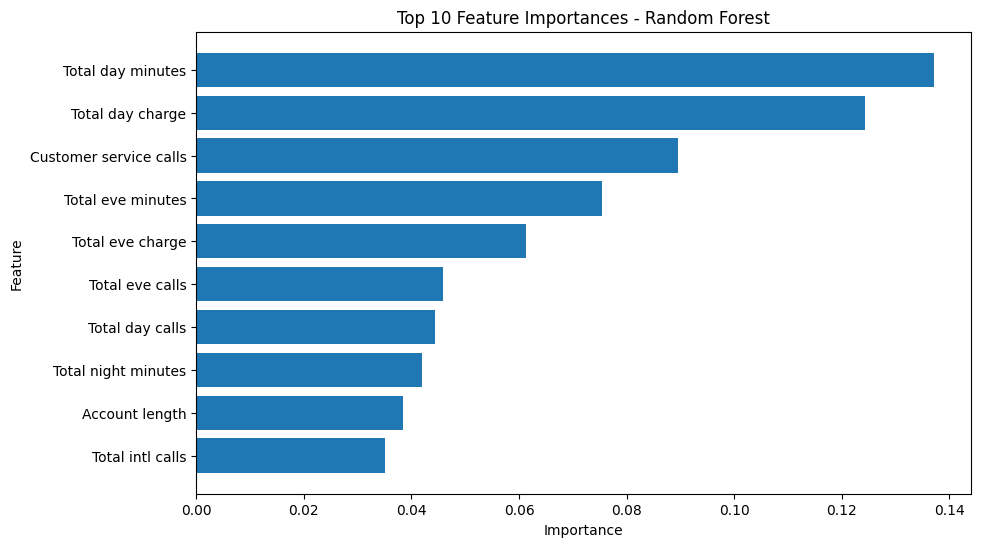

In [234]:
# Visualize the important features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'].head(10)[::-1],
    feature_importance['Importance'].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

In [235]:
# Comparison of original model and tuned model
print("Original Random Forest")
print("Accuracy:", accuracy_score(y_test, rfc.predict(X_test)))
print("F1 Score:", f1_score(y_test, rfc.predict(X_test)))

print("\nTuned Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

Original Random Forest
Accuracy: 0.8880597014925373
F1 Score: 0.4

Tuned Random Forest
Accuracy: 0.8805970149253731
F1 Score: 0.38461538461538464
